In [ ]:
# import packages here
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import c, pi
import scipy.integrate as integrate
from scipy.signal import hilbert


In [2]:
# magnification function
def mu(x):
    return 1/(1-(1/x)**4)

# amplification factor function
def F(mu, omega, td, nj): 
    return np.abs(mu)**(1/2)*np.exp(1j*omega*td - 1j*np.sign(omega)*nj*np.pi/2) 

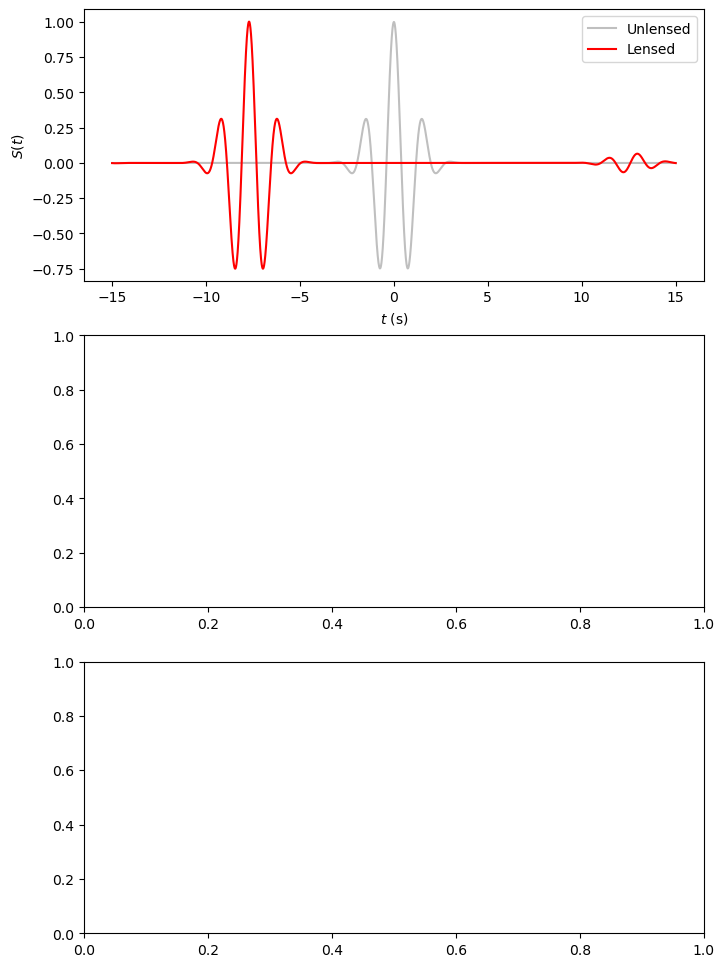

In [52]:
# signal parameters
w0 = 4.0
tM = 1.0
sigma = 1.0

t = np.linspace(-15,15,100000)
S = np.cos(w0*t/tM)*np.exp((-1.0)*(1/2*(sigma**2))*(t/tM)**2)

# calculate Fourier transform of unlensed signal
S_omega = np.fft.fftshift(np.fft.fft(np.fft.ifftshift(S)))
#S_omega = np.fft.fftshift(np.fft.fft(S))
omega = np.fft.fftshift(np.fft.fftfreq(len(t), d=t[1]-t[0])) * 2 * np.pi 

# source position
y = 3.5

# image positions
x_plus = (1/2)*np.abs(y + np.sqrt((y**2)+4))
x_minus = (1/2)*np.abs(y - np.sqrt((y**2)+4))

# image magnifications
mu_plus, mu_minus = mu(x_plus), mu(x_minus)

# morse indices
n_plus, n_minus = 0.0, 1

# time delays
td_plus = ((1/4)*((y**2) + 2 - y * np.sqrt((y**2)+4)) - np.log(x_plus))*tM
td_minus = ((1/4)*((y**2) + 2 + y * np.sqrt((y**2)+4)) - np.log(x_minus))*tM
td_images = np.abs(td_plus-td_minus)

# total amplification factor
F_plus = (np.abs(mu_plus)**(1/2))*np.exp(1j*omega*td_plus - 1j*np.sign(omega)*n_plus*np.pi/2)
F_minus = (np.abs(mu_minus)**(1/2))*np.exp(1j*omega*td_minus - 1j*np.sign(omega)*n_minus*np.pi/2)
F = F_plus + F_minus 

# calculate lensed signals
SL_prod = S_omega * F
SL = np.fft.fftshift(np.fft.ifft(np.fft.ifftshift(SL_prod)))
#SL = np.fft.fftshift(np.fft.ifft((SL_omega)))
SL_shifted = np.roll(SL.real, -30000)

# calculate fourier transform of the lensed signal
#SL_omega_2 = np.fft.fftshift(np.fft.fft(np.fft.ifftshift(SL)))

# plot results
fig.clear()
fig, ax = plt.subplots(nrows=3, figsize=(8,12))

ax[0].plot(t, S, label='Unlensed', color='black', alpha=0.25)
ax[0].plot(t, SL_shifted, label='Lensed', color='red')
ax[0].legend()

ax[0].set_xlabel(r'$t$ (s)')
ax[0].set_ylabel(r'$S(t)$')

#ax[2].plot(omega[len(omega)//2:], np.abs(SL_omega_2)[len(omega)//2:])
#ax[2].set_ylabel(r"$S(\omega)$")
#ax[2].set_xlabel(r"$\omega$")
#ax[2].set_xlim(0,50)

plt.show()